# Regressão Linear com NumPy

## Objetivos deste experimento

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se programação totalmente NumPy com:
- o **cálculo do gradiente**,
- a **função de perda** e
- a atualização dos parâmetros são feitos de forma explícita.
- A rede é criada com uma camada como uma classe

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt   # para plotting

from sklearn.datasets import load_iris  # para carregar dataset

import numpy as np  # processamento matricial

np.random.seed(1234)

## Dataset

### Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1]
y_train = data[:,1:2]

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float64
y_train.shape: (50, 1) float64
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()

Text(0, 0.5, 'Comprimento petalas')

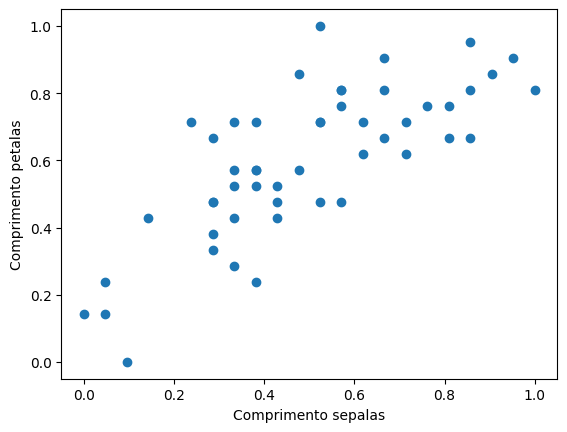

In [4]:
plt.scatter(x_train,y_train)
plt.xlabel('Comprimento sepalas')
plt.ylabel('Comprimento petalas')

## Modelo da rede

### Reta de ajuste

A equação da reta no plano necessita de dois parâmetros, aqui denominados $w_0$ (*bias*) e inclinação $w_1$. Veja figura:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/linhareta.png)

A reta de ajuste será dada por:

$$ \hat{y} = w_0 + w_1 x $$

onde
* $w_1$ é o coeficiente angular da reta e
* $w_0$ é a interseção do eixo vertical quando x é igual a zero, também denominado de *bias*.
* $x$ é a variável de entrada (comprimento das sépalas) e
* $\hat{y}$ é a predição (comprimento estimado das pétalas).

### Linear Regression Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

### Formulação matricial do neurônio

* $\mathbf{w} = [w_0 \ w_1]$ é vetor linha de parâmetros e
* $\mathbf{x} = [1 \ x_0] $ é vetor linha de uma amostra (com *bias*).

$$ \hat{y} = 1 w_0 + x_0 w_1 $$

$$ [\hat{y}] = [1 \ x_0] \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} $$

$$ \mathbf{\hat{y}} = \mathbf{x} \mathbf{w^T} $$

### Fazendo o predict de várias amostras

$$ \begin{matrix}
\begin{bmatrix}
\hat{y}_0\\
\hat{y}_1\\
\\
\hat{y}_{M-1}
\end{bmatrix} &=& \begin{bmatrix}
1 & x_0 \\
1 & x_1\\
\\
1 & x_{M-1} \\
\end{bmatrix}
&
\begin{bmatrix}
w_0\\
w_1
\end{bmatrix} \\
(M,1) & & (M,2) & (2,1) \\
\end{matrix} $$

### Preenchendo x com coluna de 1's para bias

In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428571],
       [1.        , 0.95238095],
       [1.        , 0.28571429],
       [1.        , 0.76190476],
       [1.        , 0.38095238],
       [1.        , 0.66666667],
       [1.        , 0.        ],
       [1.        , 0.80952381],
       [1.        , 0.14285714],
       [1.        , 0.04761905],
       [1.        , 0.47619048],
       [1.        , 0.52380952],
       [1.        , 0.57142857],
       [1.        , 0.33333333],
       [1.        , 0.85714286],
       [1.        , 0.33333333],
       [1.        , 0.42857143],
       [1.        , 0.61904762],
       [1.        , 0.33333333],
       [1.        , 0.47619048],
       [1.        , 0.57142857],
       [1.        , 0.66666667],
       [1.        , 0.57142857],
       [1.        , 0.71428571],
       [1.        , 0.80952381],
       [1.        , 0.9047619 ],
       [1.        , 0.85714286],
       [1.        , 0.52380952],
       [1.        , 0.38095238],
       [1.

### Classe com o modelo da rede

In [7]:
class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1,0.1,(n_out,n_in)) #inicialização dos parâmetros

    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

### Criando a rede, instanciando o objeto model

In [8]:
model = Net(2,1) # duas entradas (1 + x0) e uma saída y_pred

### Testando o predict da rede (mesmo sem treiná-la)

In [9]:
xin = np.random.randn(4,2) # 4 amostras, 2 entradas (1 + x0)
ypred = model.forward(xin)
ypred

array([[-0.09602795],
       [ 0.0661236 ],
       [-0.06857828],
       [-0.05573871]])

## Treinamento via gradiente descendente

Função de perda:
$$ J(\hat{y_i},y_i) = \frac{1}{M} \sum_{i=0}^{M-1} (\hat{y_i} - y_i)^2 $$

Gradiente:
$$  \mathbf{\nabla{J_w}} = \frac{2}{M}\mathbf{x^T}(\mathbf{x w^T} - \mathbf{y}) $$

Atualização dos parâmetros pelo gradiente descendente:
$$ \mathbf{w} = \mathbf{w} − \eta (\mathbf{\nabla J_w})^T $$

### Laço de treinamento

In [10]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):

    # forward - predict
    y_pred = model.forward(x_train_bias)

    #loss cálculo da função de perda
    loss = np.square(y_pred - y_train).mean()

    # cálculo do gradiente pelas derivadas parciais
    w_grad = (2.0/n_samples) * (x_train_bias.T).dot(x_train_bias.dot(model.w.T) - y_train)

    # gradiente descendente
    model.w = model.w - learning_rate * w_grad.T

    # verbose
    if (epoch+1) % 1 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss))

Epoch[1/100], loss: 0.469163
Epoch[2/100], loss: 0.058070
Epoch[3/100], loss: 0.030543
Epoch[4/100], loss: 0.028105
Epoch[5/100], loss: 0.027364
Epoch[6/100], loss: 0.026787
Epoch[7/100], loss: 0.026269
Epoch[8/100], loss: 0.025799
Epoch[9/100], loss: 0.025373
Epoch[10/100], loss: 0.024986
Epoch[11/100], loss: 0.024634
Epoch[12/100], loss: 0.024315
Epoch[13/100], loss: 0.024025
Epoch[14/100], loss: 0.023762
Epoch[15/100], loss: 0.023524
Epoch[16/100], loss: 0.023307
Epoch[17/100], loss: 0.023110
Epoch[18/100], loss: 0.022931
Epoch[19/100], loss: 0.022769
Epoch[20/100], loss: 0.022622
Epoch[21/100], loss: 0.022488
Epoch[22/100], loss: 0.022366
Epoch[23/100], loss: 0.022256
Epoch[24/100], loss: 0.022156
Epoch[25/100], loss: 0.022065
Epoch[26/100], loss: 0.021983
Epoch[27/100], loss: 0.021908
Epoch[28/100], loss: 0.021840
Epoch[29/100], loss: 0.021778
Epoch[30/100], loss: 0.021722
Epoch[31/100], loss: 0.021671
Epoch[32/100], loss: 0.021625
Epoch[33/100], loss: 0.021583
Epoch[34/100], loss

## Avaliação

### Predict

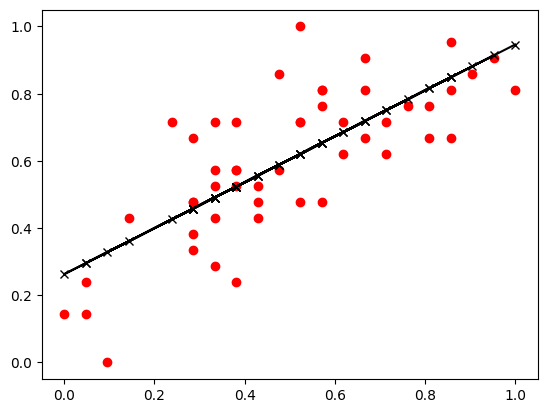

In [11]:
y_pred = model.forward(x_train_bias)
plt.plot(x_train, y_train, 'ro', label='Original data')
plt.plot(x_train, y_pred, 'kx-', label='Fitting Line')

### Parâmetros treinados

In [12]:
print(model.w)

[[0.26295353 0.68335641]]


### Avaliação do modelo

In [13]:
loss = np.square(y_pred - y_train).mean()
loss

np.float64(0.02117000379151052)

### Valor ótimo, solução analítica

$$  \mathbf{w} =(\mathbf{x^T} \mathbf{x})^{−1}\mathbf{x^T} \mathbf{y} $$

In [14]:
x = x_train_bias
y = y_train
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print(w_opt.T)

[[0.26134159 0.68646976]]


# Exercícios

## Questões

1. Quantos parâmetros são treinados nesse modelo?

2. Qual é o número de atributos de entrada para a rede?

3. Qual é o número de saídas da rede?

4. Suponha que eu tenha agora 5 mil amostras para fazer a predição. Qual é o shape da matriz de entrada?
   Qual é o shape do matriz de saída?


## Atividades

1. Modifique o laço do treinamento via gradiente descendente para guardar em uma lista, o valor da perda no final
   de cada época. Após o treinamento, plote o valor da perda em função da época.
2. Calcule o valor da perda (MSE) da rede com os parâmetros inicializados, sem serem treinados.
3. Coloque os valores dos pesos da solução ótima analítica no modelo da rede e calcule o valor da perda (MSE) e
   compare com o valor da perda obtida pelo método da otimização via gradiente descendente.

# Aprendizados

---
## Respostas às Questões

**Nome:** Thiago Pereira Magalhães | **Email:** tpm3@cesar.school

### Q1. Quantos parâmetros são treinados nesse modelo?
O modelo possui **2 parâmetros**: $w_0$ (bias) e $w_1$ (coeficiente angular). Ambos compõem o vetor de pesos $\mathbf{w} = [w_0, w_1]$.

### Q2. Qual é o número de atributos de entrada para a rede?
A rede recebe **1 atributo** de entrada (comprimento das sépalas). A coluna de 1s adicionada ao `x_train_bias` é apenas um artifício para incorporar o bias na multiplicação matricial — não é um atributo original do dataset.

### Q3. Qual é o número de saídas da rede?
A rede possui **1 saída** ($\hat{y}$): a predição do comprimento das pétalas.

### Q4. Shape com 5.000 amostras?
- **Entrada (`x_train_bias`):** shape `(5000, 2)` — 5.000 linhas × 2 colunas (coluna de 1s + atributo).
- **Saída (`y_pred`):** shape `(5000, 1)` — 5.000 predições escalares.


## Atividade 1 — Plot da Perda por Época


MSE ANTES do treinamento: 0.469163
MSE APÓS  o treinamento: 0.021170


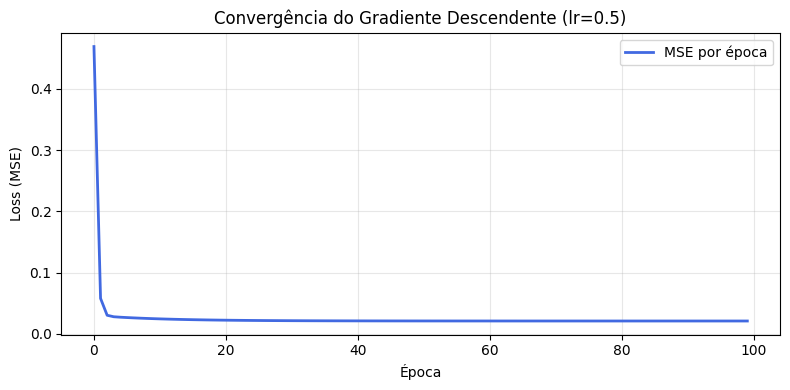

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

np.random.seed(1234)

# Recarregar dados
iris = load_iris()
data = iris.data[iris.target==1,::2]
x_train_act = data[:,0:1].copy()
y_train_act = data[:,1:2].copy()
n_samples_act = x_train_act.shape[0]

x_train_act -= x_train_act.min()
x_train_act /= x_train_act.max()
y_train_act -= y_train_act.min()
y_train_act /= y_train_act.max()

x_bias_act = np.hstack([np.ones((n_samples_act,1)), x_train_act])

class Net():
    def __init__(self, n_in, n_out):
        self.w = np.random.uniform(-0.1, 0.1, (n_out, n_in))
    def forward(self, x_bias):
        return x_bias.dot(self.w.T)

model_act = Net(2, 1)

# Atividade 2: Loss antes do treinamento
y_pred_initial = model_act.forward(x_bias_act)
loss_initial = np.square(y_pred_initial - y_train_act).mean()
print(f'MSE ANTES do treinamento: {loss_initial:.6f}')

# Atividade 1: Treinamento guardando loss por época
num_epochs = 100
learning_rate = 0.5
loss_history = []

for epoch in range(num_epochs):
    y_pred = model_act.forward(x_bias_act)
    loss = np.square(y_pred - y_train_act).mean()
    loss_history.append(loss)
    w_grad = (2.0/n_samples_act) * (x_bias_act.T).dot(x_bias_act.dot(model_act.w.T) - y_train_act)
    model_act.w = model_act.w - learning_rate * w_grad.T

print(f'MSE APÓS  o treinamento: {loss_history[-1]:.6f}')

# Plot
plt.figure(figsize=(8,4))
plt.plot(loss_history, color='royalblue', linewidth=2, label='MSE por época')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Convergência do Gradiente Descendente (lr=0.5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Atividade 3 — Comparação: Gradiente Descendente vs. Solução Analítica


In [16]:
# Solução ótima analítica
x = x_bias_act
y = y_train_act
w_opt = (np.linalg.inv((x.T).dot(x)).dot(x.T)).dot(y)
print('Pesos ótimos (analítico):', w_opt.T)
print('Pesos treinados (GD):    ', model_act.w)

# Calcular MSE com pesos ótimos
model_opt = Net(2, 1)
model_opt.w = w_opt.T
y_pred_opt = model_opt.forward(x_bias_act)
loss_opt = np.square(y_pred_opt - y_train_act).mean()
print(f'\nMSE (Gradiente Descendente): {loss_history[-1]:.8f}')
print(f'MSE (Solução Analítica):     {loss_opt:.8f}')
print(f'Diferença:                   {abs(loss_history[-1] - loss_opt):.2e}')


Pesos ótimos (analítico): [[0.26134159 0.68646976]]
Pesos treinados (GD):     [[0.26295353 0.68335641]]

MSE (Gradiente Descendente): 0.02117006
MSE (Solução Analítica):     0.02116942
Diferença:                   6.38e-07


## Experimento: Efeito da Taxa de Aprendizado

A seguir testamos diferentes valores de `learning_rate` para observar convergência e divergência.


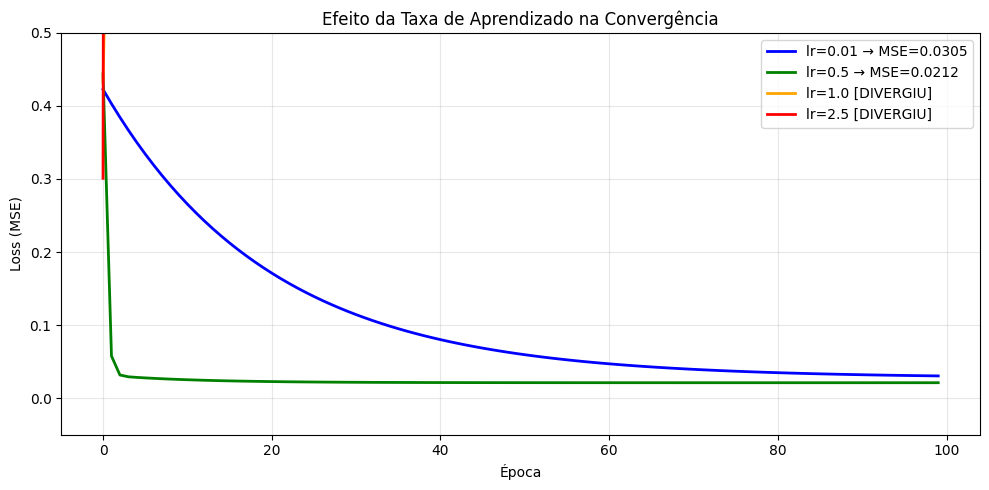

In [17]:
learning_rates = [0.01, 0.5, 1.0, 2.5]
colors_lr = ['blue', 'green', 'orange', 'red']

plt.figure(figsize=(10, 5))
for lr, color in zip(learning_rates, colors_lr):
    m = Net(2, 1)
    m.w = np.random.uniform(-0.1, 0.1, (1, 2))
    hist = []
    diverged = False
    for epoch in range(100):
        yp = m.forward(x_bias_act)
        l = np.square(yp - y_train_act).mean()
        if np.isnan(l) or l > 1e6:
            diverged = True
            break
        hist.append(l)
        wg = (2.0/n_samples_act) * (x_bias_act.T).dot(x_bias_act.dot(m.w.T) - y_train_act)
        m.w = m.w - lr * wg.T
    label = f'lr={lr}' + (' [DIVERGIU]' if diverged else f' → MSE={hist[-1]:.4f}')
    plt.plot(hist, color=color, linewidth=2, label=label)

plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Efeito da Taxa de Aprendizado na Convergência')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 0.5)
plt.tight_layout()
plt.show()


## Aprendizados

### Taxa de Aprendizado (Learning Rate)
A taxa de aprendizado $\eta$ controla o tamanho do passo na atualização: $\mathbf{w} = \mathbf{w} - \eta \nabla J_w$.

- **lr muito pequeno (ex: 0.01):** o modelo converge, mas lentamente. Pode precisar de muito mais épocas.
- **lr moderado (ex: 0.5):** convergência rápida e estável — cenário ideal.
- **lr elevado (ex: 2.5):** o gradiente 'ultrapassa' o mínimo, causando **divergência** — a loss explode.

### Solução Analítica vs. Gradiente Descendente
A solução analítica $\mathbf{w} = (X^T X)^{-1} X^T y$ encontra o mínimo exato em um único passo, mas tem custo computacional $O(n^3)$ para inverter a matriz. O gradiente descendente é iterativo mas escala bem para grandes datasets.

### Conclusão
O modelo com 2 parâmetros ($w_0$, $w_1$) consegue ajustar adequadamente a relação linear entre comprimento de sépalas e pétalas da espécie *Iris versicolor*, atingindo um MSE próximo ao ótimo analítico com apenas 100 épocas e lr=0.5.
